# Implementing Foundational ML Algorithms from scratch


----


## **KNN & LSH** (K-Nearest Neighbors & Locality-Sensitive Hashing)

#### Introduction:

In this notebook, I’m extending my collection of machine learning algorithms implemented from scratch by adding the **K-Nearest Neighbors (KNN)** classifier and enhancing it with **Locality Sensitive Hashing (LSH)** for efficient approximate search.  
KNN is one of the simplest yet powerful algorithms in machine learning, widely used for classification, recommendation, and information retrieval. LSH complements KNN by drastically reducing search time in high-dimensional spaces, making it scalable for larger datasets.

The focus here is on a pure NumPy implementation, without relying on external ML frameworks. This helps deepen the understanding of the algorithmic foundations behind document retrieval and similarity search.

#### Objectives:

- Implement document retrieval and classification using KNN and LSH:

    1- Preprocess and tokenize short tweet-like messages labeled into 4 categories (tech, sports, food, travel).

    2- Build document embeddings using simple averaging of word vectors.

    3- Implement KNN from scratch for classification and nearest-neighbor search.

    4- Evaluate performance in terms of accuracy and retrieval quality.

    5- Implement LSH from scratch for approximate nearest neighbor search.

    6- Compare the performance and recall of LSH vs. brute-force KNN.

-----


-----


## 1- Preprocess and tokenize short tweet-like messages labeled into 4 categories (tech, sports, food, travel).

### 1.1- Setup and export JSON dataset

In this step we load a small, self-contained JSON dataset (`texts_5labels.json`) with **24 short tweets** labeled across **4 categories** (tech, sports, food, travel).  
We perform a few integrity checks (file existence, size, matching counts), then preview label distribution and a few samples.  
These `texts` and `labels` will feed the next stages where we build document embeddings and apply **KNN** and **LSH** from scratch.

In [18]:
from pathlib import Path
import json
from collections import Counter

In [19]:
# Import first tiny dataset
DATA_DIR = Path("../data")
DATA_PATH = DATA_DIR / "texts_5labels.json"

# existence & size checks
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH.resolve()} "
                            f"(tip: confirm your working directory and relative path)")
    
size = DATA_PATH.stat().st_size
if size == 0:
    raise ValueError(f"Dataset file is empty: {DATA_PATH.resolve()}")

In [20]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)        

In [21]:
texts = data["texts"]
labels = data["labels"]

In [22]:
assert len(texts) == len(labels) == 24, "Dataset should have 24 texts and 24 labels."
counts = Counter(labels)

In [23]:
print("Counts per label:", dict(counts))
print("First 3 samples:")
for i in range(3):
    print(f"[{i}] ({labels[i]}) -> {texts[i]}")

Counts per label: {'tech': 6, 'sports': 6, 'food': 6, 'travel': 6}
First 3 samples:
[0] (tech) -> AI models from scratch are fun to build with numpy
[1] (tech) -> Training neural nets takes time but it’s rewarding
[2] (tech) -> Debugging Python code late at night hits different


## 2- Build document embeddings using simple averaging of word vectors.

Before turning texts into vectors, we standardize them so that different spellings map to the **same tokens** and align with our GloVe subset.  
This step is intentionally minimal and reproducible:

- Normalize curly quotes and dashes to ASCII.
- Remove URLs; strip `@`/`#` symbols but **keep the text** (e.g., `@user` → `user`, `#topic` → `topic`).
- Keep letters/digits plus apostrophes and hyphens (preserves “it’s”, “state-of-the-art”).
- Lowercase and collapse extra spaces.
- Tokenize by simple whitespace split.

The result is `tokenized_texts`, a clean list of tokens per tweet that we’ll map to **dense GloVe vectors** in the next step.

In [78]:
import re
from typing import List, Tuple, Dict
import numpy as np

### 2.1- Canonicalize and Tokenize functions

In [25]:
# Normalize quotes, apostrophes and dashes to ASCII
def _normalize_punctuation(s: str) -> str:
    s = s.replace("’", "'").replace("‘", "'")
    s = s.replace("“", '"').replace("”", '"')
    s = s.replace("—", "-").replace("–", "-")
    return s

In [26]:
# Core cleaner function:
# - Lowercase (optional)
# - Strip URLs
# - Handle @mentions and #hashtags (keep the token text, drop the symbol)
# - Keep letters/numbers/apostrophes/hyphens inside words

def clean_text(
    s: str,
    *,
    lower: bool = True,
    keep_hashtag_text: bool = True,
    keep_mention_text: bool = True,
) -> str:
    
    # Apply normalize punctuation
    s = _normalize_punctuation(s)

    # Remove URLs
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)

    # Mentions: @user -> "user" (if keep_mention_text) else removed
    if keep_mention_text:
        s = re.sub(r"@([A-Za-z0-9_]+)", r" \1 ", s)
    else:
        s = re.sub(r"@[A-Za-z0-9_]+", " ", s)

    # Hashtags: #topic -> "topic" (if keep_hashtag_text) else removed
    if keep_hashtag_text:
        s = re.sub(r"#([A-Za-z0-9_]+)", r" \1 ", s)
    else:
        s = re.sub(r"#[A-Za-z0-9_]+", " ", s)

    # Keep letters, digits, apostrophes, hyphens. Turn other punctuation into spaces
    # (allow apostrophes/hyphens inside words like: it's, state-of-the-art)
    s = re.sub(r"[^A-Za-z0-9'\-]+", " ", s)

    # Collapse multiple spaces
    s = re.sub(r"\s+", " ", s).strip()

    if lower:
        s = s.lower()

    return s

# simple tokenizer
def tokenize(s: str) -> str:
    return s.split()

In [27]:
# Apply cleaner + tokenizer
tokenized_texts = [tokenize(clean_text(t)) for t in texts]

In [28]:
# Quick preview
for i in range(3):
    print(f"[{i}] -> {tokenized_texts[i]}")

[0] -> ['ai', 'models', 'from', 'scratch', 'are', 'fun', 'to', 'build', 'with', 'numpy']
[1] -> ['training', 'neural', 'nets', 'takes', 'time', 'but', "it's", 'rewarding']
[2] -> ['debugging', 'python', 'code', 'late', 'at', 'night', 'hits', 'different']


### 2.2- Quick EDA

Before building vectors, we run a light sanity check on the tokenized corpus:

- **Document lengths:** min / max / mean / median token counts.
- **Vocabulary size** and **most frequent tokens**.
- **Stopwords presence:** we keep them here. Mean-pooled GloVe with L2-normalization is robust for short texts.

This quick pass validates that cleaning/tokenization behaved as expected and that the corpus looks reasonable before we convert tweets into dense embeddings.

In [35]:
# lengths & vocab size
lengths = np.array([len(toks) for toks in tokenized_texts], dtype=int)
vocab = Counter(tok for toks in tokenized_texts for tok in toks)

In [36]:
print(f"Docs: {len(tokenized_texts)} | Vocab size: {len(vocab)}")
print(f"Per-doc tokens — min:{lengths.min()} max:{lengths.max()} mean:{lengths.mean():.2f} median:{np.median(lengths):.1f}")

# Top tokens (optional, small peek)
for tok, freq in vocab.most_common(10):
    print(f"{tok:>12s} : {freq}")

Docs: 24 | Vocab size: 160
Per-doc tokens — min:6 max:13 mean:8.75 median:8.5
         the : 9
          my : 5
         and : 5
           a : 5
          is : 5
          to : 4
        with : 4
        from : 3
          at : 3
         was : 3


We do see common stopwords. For this notebook we keep them: mean-pooled GloVe with L2-normalization is robust for short texts.

### 2.3- Mean-pooled GloVe document embeddings

We convert each tweet into a **300-D dense vector** by averaging the GloVe vectors of its tokens:

- **Embedding source:** the compact GloVe subset built in the helper notebook (`glove_subset_vocab.json` + `glove_subset.npy`).
- **Pooling:** simple mean over token vectors (strong baseline for short texts).
- **OOV handling:** tokens not found in the subset map to `"<unk>"` at index 0, whose vector is the **mean of all found vectors** (stable fallback).
- **Normalization:** we L2-normalize each document vector so cosine similarity ≈ dot product.

This gives us an `X ∈ ℝ^{N_docs × 300}` matrix that we’ll feed into:
1) a **brute-force KNN** (cosine) as the correctness baseline, and  
2) **LSH (random hyperplanes)** to accelerate approximate nearest-neighbor search.


In [31]:
VOCAB_PATH = DATA_DIR / "glove_subset_vocab.json"
EMB_PATH   = DATA_DIR / "glove_subset.npy"

In [32]:
# Load compact vocab and embedding matrix built by the helper notebook
with VOCAB_PATH.open("r", encoding="utf-8") as f:
    stoi = json.load(f)          # token -> index, with "<unk>": 0
E = np.load(EMB_PATH)            # shape: (V, 300), float32

In [33]:
def doc_embedding_mean(tokens, stoi, E, *, use_unk=True, l2norm=True):
    """
    Mean of token vectors. If use_unk=True, unseen tokens map to index 0 (<unk>);
    otherwise they are skipped. Optionally L2-normalize the final vector.
    """
    idxs = []
    for t in tokens:
        if t in stoi:
            idxs.append(stoi[t])
        elif use_unk:
            idxs.append(0)       # <unk> row is the mean fallback we saved
        # else: skip OOV
    if not idxs:
        v = np.zeros((E.shape[1],), dtype=np.float32)
    else:
        v = E[np.array(idxs, dtype=int)].mean(axis=0)
    if l2norm:
        n = np.linalg.norm(v)
        if n > 0:
            v = v / n
    return v


In [34]:
# Build document-embedding matrix X (N_docs × 300)
X = np.vstack([doc_embedding_mean(toks, stoi, E) for toks in tokenized_texts])

print("X shape:", X.shape, "| dtype:", X.dtype)
print("Norms — min:{:.4f} max:{:.4f} mean:{:.4f}".format(
    np.linalg.norm(X, axis=1).min(),
    np.linalg.norm(X, axis=1).max(),
    np.linalg.norm(X, axis=1).mean()
))
print("First doc (first 6 dims):", np.round(X[0][:6], 4))

X shape: (24, 300) | dtype: float32
Norms — min:1.0000 max:1.0000 mean:1.0000
First doc (first 6 dims): [-0.0862  0.0149 -0.0527 -0.0507 -0.0759  0.0303]


## 3- KNN: retrieval and classification (cosine)

In this section we turn KNN into a simple text classifier and searcher:

1) **Query embedding**: A free-text query is cleaned, tokenized, and mapped to a 300-D vector via **mean-pooled GloVe**, then L2-normalized.

2) **Similarity**: We compute cosine similarity between the query and **every** document by a single dot-product pass (`X @ q`).  
   *Because vectors are unit-length, cosine ≡ dot product.*

3) **Top-k neighbors**: For clarity, we use a **full sort** (`argsort`) and then slice the top-k indices.

4) **KNN classification**: Each neighbor “votes” for its label with weight equal to its cosine score.  
   We **clamp negatives to 0** so dissimilar neighbors don’t vote *against* a class.  
   The predicted label is the one with the largest **sum of votes**, ties are broken by the label of the **single closest** neighbor.

5) **Evaluation (LOOCV)**: We estimate accuracy by **leave-one-out**: for each document, use its vector as a query, **exclude itself**, and predict its label from the remaining N−1 vectors.


In [42]:
def knn_search_cosine(X: np.ndarray, q: np.ndarray, k: int, exclude_self: int | None = None):
    """
    Readable NumPy version: compute all scores with a single matmul,
    then do a full argsort (descending) and slice top-k.
    """
    # Normalize q
    q = q.astype(np.float32, copy=False)
    q_norm = np.linalg.norm(q)
    if q_norm > 0:
        q = q / q_norm

    # Cosine = dot for unit vectors
    sims = X @ q  # shape: (N,)

    # Optionally exclude the query's own index
    if exclude_self is not None and 0 <= exclude_self < X.shape[0]:
        sims = sims.copy()
        sims[exclude_self] = -np.inf

    # Full sort (descending) for clarity
    order_desc = np.argsort(-sims)
    order_topk = order_desc[:min(k, X.shape[0])]
    return order_topk, sims[order_topk]

# Turn a free-text query into a 300-D embedding (same pipeline as docs)
def embed_query(text: str) -> np.ndarray:
    toks = tokenize(clean_text(text))
    return doc_embedding_mean(toks, stoi, E)  # L2-normalized mean-pooled GloVe



In [44]:
# Weighted voting over the top-k neighbors to classify the query
def knn_predict_weighted(
    X: np.ndarray,
    labels: list[str],
    q_vec: np.ndarray,
    k: int = 5,
    *,
    nonneg: bool = True,
    exclude_self: int | None = None,
):
    """
    Classify q_vec by retrieving its top-k neighbors and doing a weighted vote.
    Weights are cosine similarities (optionally clamped at 0 to avoid negatives).
    Returns (pred_label, neighbors_indices, neighbors_scores, label_weights_dict).
    """
    nbr_idx, nbr_scores = knn_search_cosine(X, q_vec, k=k, exclude_self=exclude_self)

    # Aggregate cosine-based votes per label.
    # Idea: each of the k neighbors "votes" for its class with strength equal to its cosine similarity.
    # We sum those votes by class and pick the class with the largest total.
    weights: dict[str, float] = {}

    for j, s in zip(nbr_idx, nbr_scores):
        # s is the cosine similarity between the query and neighbor j (range [-1, 1]).
        # If nonneg=True, we clamp negative similarities to 0 so dissimilar neighbors
        # do not "vote against" a class. If nonneg=False, negatives subtract from the total.
        w = float(max(s, 0.0)) if nonneg else float(s)

        # Look up the class label of neighbor j.
        lab = labels[j]

        # Add this neighbor's vote to its class total.
        # weights.get(lab, 0.0) returns 0.0 if 'lab' has not been seen yet.
        weights[lab] = weights.get(lab, 0.0) + w

    # Pick the label with the largest total weight
    # Tie-breaker: if equal, prefer the label of the single highest-scoring neighbor
    best_label = max(weights.items(), key=lambda kv: kv[1])[0]
    
    # tie handling
    tied_labels = [lab for lab, w in weights.items() if abs(w - weights[best_label]) < 1e-12]
    if len(tied_labels) > 1:
        # choose label of the top-1 neighbor among the tied set
        for j, s in zip(nbr_idx, nbr_scores):
            if labels[j] in tied_labels:
                best_label = labels[j]
                break

    return best_label, nbr_idx, nbr_scores, weights


In [45]:
# Demo with a free-text query
query_text = "Reading about neural networks in Python and NumPy from scratch"
q_vec = embed_query(query_text)
pred, nbr_idx, nbr_scores, weights = knn_predict_weighted(X, labels, q_vec, k=5)

In [60]:
print("Query:", query_text)
print("Predicted label:", pred)
print("Neighbor votes (weighted by cosine):", {k: round(v, 3) for k, v in weights.items()})
print("\nTop-k neighbors (idx, label, score):")
for j, s in zip(nbr_idx, nbr_scores):
    snippet = texts[j][:70] + ("..." if len(texts[j]) > 70 else "")
    print(f"  {j:2d}  {labels[j]:>6s}  {s: .4f}  -> {snippet}")

# Leave-one-out accuracy on the 24 docs
def loocv_accuracy(X: np.ndarray, labels: list[str], k: int = 5) -> float:
    correct = 0
    for i in range(X.shape[0]):
        pred_i, _, _, _ = knn_predict_weighted(X, labels, X[i], k=k, exclude_self=i)
        correct += int(pred_i == labels[i])
    return correct / X.shape[0]

acc = loocv_accuracy(X, labels, k=4)
print(f"\nLeave-one-out KNN accuracy (k=4): {acc*100:.1f}%")



Query: Reading about neural networks in Python and NumPy from scratch
Predicted label: tech
Neighbor votes (weighted by cosine): {'tech': 2.8, 'travel': 0.651}

Top-k neighbors (idx, label, score):
   0    tech   0.7488  -> AI models from scratch are fun to build with numpy
   1    tech   0.6936  -> Training neural nets takes time but it’s rewarding
   2    tech   0.6887  -> Debugging Python code late at night hits different
   5    tech   0.6683  -> Reading papers on embeddings and LSH to speed up search
  22  travel   0.6507  -> Exploring old town by bike is my favorite way to see a city

Leave-one-out KNN accuracy (k=4): 58.3%


### 4- Visualization
#### 4.1- PCA (2D) of document embeddings

We project the 300-D mean-pooled GloVe vectors to 2D with PCA to **visualize structure**:
- One marker per label.
- Optional point annotations with the document index.
- Title shows explained variance for PC1/PC2.

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [64]:
# 1) Fit PCA on X and transform to 2D
pca = PCA(n_components=2, svd_solver="auto", random_state=0)
Z = pca.fit_transform(X)  # shape: (N_docs, 2)

In [65]:
# 2) Report explained variance
var = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={var[0]*100:.1f}%, PC2={var[1]*100:.1f}%, total={var.sum()*100:.1f}%")

PCA explained variance: PC1=18.3%, PC2=9.7%, total=28.0%


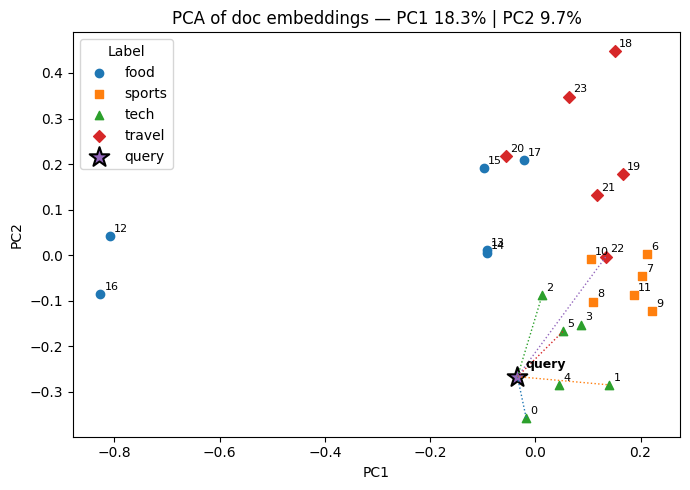

In [77]:
# 3) Scatter with distinct markers per label
unique_labels = sorted(set(labels))
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X']
marker_map = {lab: marker_cycle[i % len(marker_cycle)] for i, lab in enumerate(unique_labels)}

plt.figure(figsize=(7, 5))
for lab in unique_labels:
    idxs = [i for i, y in enumerate(labels) if y == lab]
    plt.scatter(Z[idxs, 0], Z[idxs, 1], marker=marker_map[lab], label=lab)

# Annotate each point with its doc index
for i, (x, y) in enumerate(Z):
    plt.annotate(str(i), (x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)

# Project the query into the same PCA space
Z_q = pca.transform(q_vec.reshape(1, -1))[0]  # shape (2,)

# Plot the query as a large star with a black edge
plt.scatter([Z_q[0]], [Z_q[1]],
            marker='*', s=220, linewidths=1.5, edgecolors='k', label='query')
plt.annotate("query", (Z_q[0], Z_q[1]),
             xytext=(6, 6), textcoords="offset points", fontsize=9, weight='bold')

# draw light dotted lines from the query to its current top-k neighbors:
DRAW_EDGES = True
if DRAW_EDGES:
    for j in nbr_idx:
        plt.plot([Z_q[0], Z[j, 0]], [Z_q[1], Z[j, 1]], linestyle=':', linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of doc embeddings — PC1 {var[0]*100:.1f}% | PC2 {var[1]*100:.1f}%")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


- Each point is a tweet’s **300-D embedding** projected to **2D with PCA**; markers/colors show the true label and numbers are **doc indices**.
- The **purple star** is the **query**. Dotted lines connect the query to its **top-k neighbors** (by cosine KNN).
- Title shows **explained variance** (e.g., PC1 ≈ 18.3%, PC2 ≈ 9.7%), so this 2D view summarizes roughly ~28% of the geometry.
- Visible structure:
  - **tech** (△) clusters toward the lower-right,
  - **sports** (■) sits right/center,
  - **travel** (◆) spreads upper-right,
  - **food** (●) is mostly left (e.g., docs 12, 16 clearly separated).
- The query lands inside the **tech** region and links primarily to tech neighbors; a nearby **travel** neighbor also appears, reflecting some cross-topic similarity in short texts.
- Use this plot for **intuition**, not exact distances—PCA compresses high-D structure, so neighborhood relations are best judged by cosine in the original 300-D space.

#### 4.2- Top-k neighbor scores (bar chart)

For the last query we ran, visualize the cosine scores of its top-k neighbors.

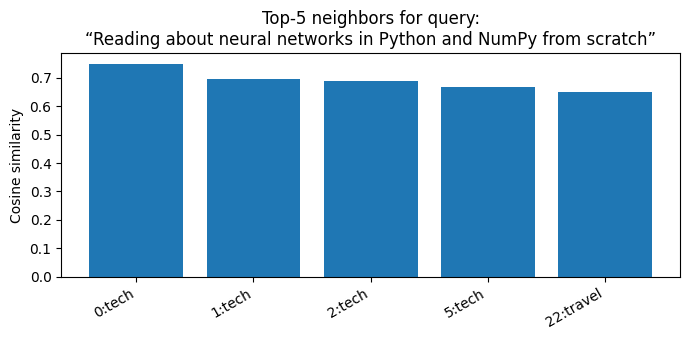

In [70]:
# Build short labels: "<idx>:<class>"
bar_labels = [f"{j}:{labels[j]}" for j in nbr_idx]
bar_vals = np.asarray(nbr_scores, dtype=np.float32)

plt.figure(figsize=(7, 3.5))
plt.bar(np.arange(len(bar_vals)), bar_vals)
plt.xticks(np.arange(len(bar_vals)), bar_labels, rotation=30, ha="right")
plt.ylabel("Cosine similarity")
plt.title(f"Top-{len(bar_vals)} neighbors for query:\n“{query_text}”")
plt.tight_layout()
plt.show()

- Each bar is one nearest neighbor shown as `<doc_index>:<true_label>`.
- The bar height is the **cosine similarity** between the query embedding and that document (1 = very similar, 0 = unrelated).
- Here, the top four neighbors are **tech** with high scores (~0.67–0.75).  
  The 5th (`22:travel`) still scores ~0.65, so it appears in top-k.
- For KNN classification, we **sum these scores by label** (weighted vote).  
  Tech’s total > Travel’s, so the predicted label is **tech**.


#### 4.3- Cosine similarity heatmap (N × N)

A quick sanity check: with unit-length vectors, the cosine matrix is `S = X·Xᵀ`.
We should see **blocks** of higher similarity within the same class.

In [72]:
from collections import defaultdict

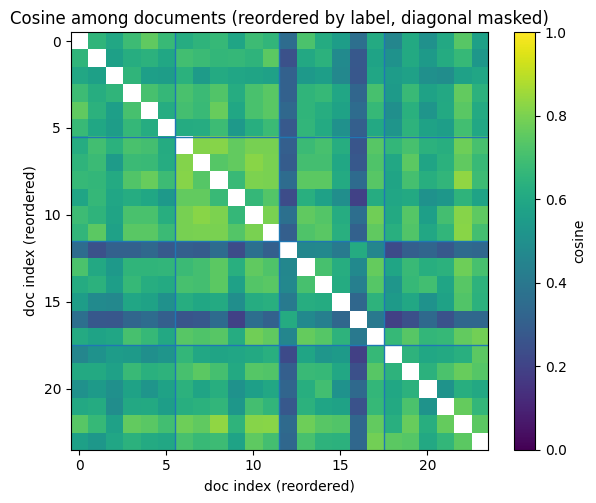

In [73]:
S = X @ X.T

lbl_to_idx = defaultdict(list)
for i, y in enumerate(labels):
    lbl_to_idx[y].append(i)

order_labels = ["tech","sports","food","travel"]  # or sorted(lbl_to_idx)
order = [i for lab in order_labels if lab in lbl_to_idx for i in lbl_to_idx[lab]]

S_ord = S[np.ix_(order, order)].copy()
np.fill_diagonal(S_ord, np.nan)  # hide the 1.0 diagonal

plt.figure(figsize=(6,5))
plt.imshow(S_ord, interpolation="nearest", vmin=0, vmax=1)  # same scale, clearer contrast
# draw grid lines at class boundaries
cuts = np.cumsum([len(lbl_to_idx[lab]) for lab in order_labels if lab in lbl_to_idx])[:-1]
for c in cuts:
    plt.axhline(c-0.5, linewidth=1)
    plt.axvline(c-0.5, linewidth=1)
plt.title("Cosine among documents (reordered by label, diagonal masked)")
plt.xlabel("doc index (reordered)"); plt.ylabel("doc index (reordered)")
plt.colorbar(label="cosine"); plt.tight_layout(); plt.show()


- After reordering by label, you can see **faint diagonal blocks**: within-class pairs are a bit warmer than cross-class, but separation is **not sharp**.
- The fairly uniform green background implies many pairs have **moderate cosine** (≈0.5–0.7)—typical for **mean-pooled GloVe** on short texts with stopwords and an `<unk>` fallback.
- This explains the occasional **cross-topic neighbors** and the ~50–60% LOOCV accuracy rather than near-perfect clustering.

### 5- Locality-Sensitive Hashing (LSH) for cosine

**Why:** Brute-force KNN scores a query against **all N vectors** (O(N·D)).  
**LSH** shrinks this to a small **candidate set**: we hash vectors so that **similar items land in the same bucket with high probability**, then re-rank only those candidates by exact cosine.

**Random-hyperplane LSH for cosine (SimHash):**
- For each hash table, draw **B random hyperplanes** $r_b \sim \mathcal N(0,I)$.
- For a vector $x$, compute **B bits**:  
  $b_b = \mathbb{1}[r_b \cdot x \ge 0]$.  
  (Bit says which side of hyperplane $r_b$ the vector lies on.)
- The **B-bit key** indexes a bucket. We build **L independent tables**; at query time we:
  1) hash the query to a key per table,  
  2) **union** all bucket contents (candidates),  
  3) compute **exact cosine** on candidates and take top-k.

**Tuning trade-offs:**
- **B (bits per table):** bigger B → **smaller buckets** (faster) but **lower recall**.  
- **L (tables):** more tables → **higher recall** (more candidates) but more work.

In [81]:
# Hash utilities
def make_hyperplanes(dim: int, n_bits: int, rng: np.random.Generator) -> np.ndarray:
    """
    Draw n_bits random hyperplanes ~ N(0, I). Shape: (n_bits, dim).
    (No need to normalize. Only the sign of the dot matters.)
    """
    return rng.normal(size=(n_bits, dim)).astype(np.float32)

def sign_bits(vec: np.ndarray, planes: np.ndarray) -> Tuple[int, ...]:
    """
    Return the tuple of 0/1 bits for (planes @ vec >= 0).
    planes: (n_bits, dim), vec: (dim,)
    """
    proj = planes @ vec  # (n_bits,)
    bits = (proj >= 0).astype(np.uint8)
    return tuple(int(b) for b in bits)  # tuple is hashable → dict key

About the previous two functions:
- **make_hyperplanes**: Returns a matrix whose rows are hyperplane normals. Gaussian is convenient; any symmetric distribution works because we only use the sign of the dot product.
- **sign_bits**: Projects vec onto each hyperplane (planes @ vec) and emits 0/1 bits depending on the sign. The result is a tuple (immutable, hashable) so it can be used as a dict key: table[key] -> [doc indices].

In [82]:
# Index building

def build_lsh_index(
    X: np.ndarray,
    L: int = 8,              # number of tables
    B: int = 8,              # bits per table
    seed: int = 23
) -> Tuple[List[np.ndarray], List[Dict[Tuple[int, ...], List[int]]]]:
    """
    Build LSH with L tables of B bits each.
    Returns:
      - planes_list: list of (B, D) hyperplane matrices
      - tables: list of dicts: key(bit-tuple) -> list of doc indices
    """
    rng = np.random.default_rng(seed)
    D = X.shape[1]
    planes_list: List[np.ndarray] = []
    tables: List[Dict[Tuple[int, ...], List[int]]] = []

    for t in range(L):
        planes = make_hyperplanes(D, B, rng)
        planes_list.append(planes)
        table: Dict[Tuple[int, ...], List[int]] = {}
        for i in range(X.shape[0]):
            key = sign_bits(X[i], planes)
            table.setdefault(key, []).append(i)
        tables.append(table)
    return planes_list, tables


- **build_lsh_index**: creates the LSH data structure for cosine search. Given the document matrix `X` (N×D), it builds **L independent hash tables**. In each table, it first samples **B random hyperplanes** (shape B×D), then hashes **every row of `X`** into a **B-bit key** via `sign_bits` and stores the document index in the bucket `table[key]`. The function returns `(planes_list, tables)`: the list of per-table hyperplane matrices (needed later to hash queries with the **same** planes) and the list of Python dicts mapping each bit-tuple to the list of doc indices in that bucket. `seed` makes the random hyperplanes reproducible


In [111]:
# Query with LSH
def lsh_candidates(
    q: np.ndarray,
    planes_list: List[np.ndarray],
    tables: List[Dict[Tuple[int, ...], List[int]]]
) -> List[int]:
    """
    Union of candidate indices across all tables where the query falls.
    """
    cand = set()
    for planes, table in zip(planes_list, tables):
        key = sign_bits(q, planes)
        if key in table:
            cand.update(table[key])
    return sorted(cand)

def lsh_query_topk(
    X: np.ndarray,
    q: np.ndarray,
    planes_list: List[np.ndarray],
    tables: List[Dict[Tuple[int, ...], List[int]]],
    k: int = 5,
    exclude_self: int | None = None,
):
    """
    Use LSH to get a candidate set, then rank candidates by cosine and return top-k.
    Falls back to all docs if the candidate set is empty.
    Returns: (idx_topk, scores_topk, candidate_count)
    """
    # Ensure q is unit-length (cosine == dot)
    q = q.astype(np.float32, copy=False)
    n = np.linalg.norm(q)
    if n > 0:
        q = q / n

    cand = lsh_candidates(q, planes_list, tables)
    
    if exclude_self is not None:
        cand = [j for j in cand if j != exclude_self]
        
    if len(cand) == 0:
        cand = list(range(X.shape[0]))  # fallback: brute-force

    cand = np.array(cand, dtype=int)
    scores = X[cand] @ q
    order = np.argsort(-scores)[:min(k, len(cand))]
    return cand[order], scores[order], len(cand)

- **lsh_candidates**: hashes the query `q` with the **same hyperplanes** used at index time (one key per table), then for each table looks up the bucket `table[key]` and **unions** all retrieved doc indices. Returns a **sorted list of unique candidates** drawn from the matching buckets across all `L` tables.
- **lsh_query_topk**: L2-normalizes `q` (so cosine ≡ dot), calls `lsh_candidates` to get the reduced search set, and if it’s empty **falls back to all docs**. It then computes cosine scores **only over candidates** (`X[cand] @ q`), sorts them descending, and returns the **top-k indices**, their **scores**, and the **candidate_count** (useful to see how much the search space shrank). Recall/speed is controlled by `B` (bits per table) and `L` (tables).


#### 5.1- Build the LSH index (set L and B)

In [112]:
L_TABLES = 8     
B_BITS   = 8     
planes_list, tables = build_lsh_index(X, L=L_TABLES, B=B_BITS, seed=23)

print(f"Built LSH index: L={L_TABLES}, B={B_BITS}")

# show bucket occupancy in the first table
sizes = [len(v) for v in tables[0].values()]
print(f"Table[0] buckets: {len(sizes)} non-empty | avg size={np.mean(sizes):.2f} | max={np.max(sizes)}")


Built LSH index: L=8, B=8
Table[0] buckets: 16 non-empty | avg size=1.50 | max=4


Here, `sizes` holds the number of vectors in each non-empty bucket of the first hash table (`tables[0]`, built from the first set of random hyperplanes). Note that the **sum of these counts equals 24**, the number of documents, because each document is assigned to exactly one bucket per table

In [113]:
sizes

[2, 1, 3, 1, 2, 1, 1, 2, 1, 1, 1, 4, 1, 1, 1, 1]

In [114]:
sum(sizes)

24

#### 5.2- Compare LSH vs brute-force for the same free-text query

In [116]:
# Reuse the previous query_text and q_vec (or define a new query_text)
# query_text = "Reading about neural networks in Python and NumPy from scratch"
# q_vec = embed_query(query_text)

# LSH search
lsh_idx, lsh_scores, cand_count = lsh_query_topk(X, q_vec, planes_list, tables, k=5)

# Brute-force (for reference)
bf_idx, bf_scores = knn_search_cosine(X, q_vec, k=5)

In [117]:
print(f"Query: {query_text}")
print(f"LSH candidates: {cand_count} / {len(texts)} (smaller is faster)")
print("\nLSH top-5 (idx, label, cosine):")
for j, s in zip(lsh_idx, lsh_scores):
    print(f"  {j:2d}  {labels[j]:>6s}  {s: .4f}  -> {texts[j][:60]}{'...' if len(texts[j])>60 else ''}")

print("\nBrute-force top-5 (idx, label, cosine):")
for j, s in zip(bf_idx, bf_scores):
    print(f"  {j:2d}  {labels[j]:>6s}  {s: .4f}  -> {texts[j][:60]}{'...' if len(texts[j])>60 else ''}")

# Simple overlap metric (recall@k relative to brute-force)
overlap = len(set(lsh_idx) & set(bf_idx))
print(f"\nOverlap with brute-force top-5: {overlap}/5 (recall@5 = {overlap/5:.2f})")


Query: Reading about neural networks in Python and NumPy from scratch
LSH candidates: 10 / 24 (smaller is faster)

LSH top-5 (idx, label, cosine):
   0    tech   0.7488  -> AI models from scratch are fun to build with numpy
   1    tech   0.6936  -> Training neural nets takes time but it’s rewarding
   2    tech   0.6887  -> Debugging Python code late at night hits different
   5    tech   0.6683  -> Reading papers on embeddings and LSH to speed up search
   3    tech   0.6069  -> Just pushed code to my GitHub repo, happy with the cleanup

Brute-force top-5 (idx, label, cosine):
   0    tech   0.7488  -> AI models from scratch are fun to build with numpy
   1    tech   0.6936  -> Training neural nets takes time but it’s rewarding
   2    tech   0.6887  -> Debugging Python code late at night hits different
   5    tech   0.6683  -> Reading papers on embeddings and LSH to speed up search
  22  travel   0.6507  -> Exploring old town by bike is my favorite way to see a city

Overlap with b

**Speed-up**: LSH shrank the search from 24 → 10 candidates (≈58% fewer dot products) and still recovered 4 of the top-5 brute-force neighbors.

**Recall**: recall@5 = 0.80 means LSH missed one true top-5 neighbor (doc 22: travel).
Interestingly, the LSH top-5 ended up all tech, which actually aligns better with the query’s intent—so you traded a bit of recall for a cleaner candidate set.

**Conclusion**: With L=8, B=8 we’re in a reasonable operating point: noticeable pruning with only a modest recall drop. This is exactly the LSH trade-off: fewer candidates → faster, but lower recall.

#### 5.3- Corpus-wide evaluation: recall@k and candidate count

We compare LSH to brute-force using **leave-one-out** across all 24 docs.
- For each doc \(i\): use its vector as the query, **exclude itself**, and compute
  - brute-force top-k neighbors,
  - LSH top-k after hashing, **then exact re-ranking**.
- Metrics: **recall@k** (overlap with brute-force top-k) and **candidate_count** (how many docs were re-ranked exactly after hashing).


In [118]:
def evaluate_lsh_corpus(
    X: np.ndarray,
    L: int,
    B: int,
    ks: List[int] = [1, 3, 5],
    seed: int = 123,
) -> Dict[str, float]:
    """
    Build an LSH index and evaluate recall@k vs brute-force over all docs (LOO).
    Returns a dict with mean recall@k and candidate count stats.
    """
    ks = sorted(ks)
    Kmax = ks[-1]

    # Build index once
    planes_list, tables = build_lsh_index(X, L=L, B=B, seed=seed)

    recalls = {k: [] for k in ks}
    cand_counts = []

    N = X.shape[0]
    for i in range(N):
        q = X[i]

        # Brute-force reference (exclude self)
        bf_idx_full, _ = knn_search_cosine(X, q, k=Kmax, exclude_self=i)

        # LSH: get a single candidate set & top-Kmax, reuse its prefixes for each k
        lsh_idx_full, _, cand_count = lsh_query_topk(X, q, planes_list, tables, k=Kmax, exclude_self=i
)
        cand_counts.append(cand_count)

        # Recall@k: fraction of brute-force top-k recovered by LSH top-k
        bf_set_prefix = set()
        lsh_set_prefix = set()
        for k in ks:
            bf_set_prefix.update(bf_idx_full[:k])
            lsh_set_prefix.update(lsh_idx_full[:k])
            overlap = len(bf_set_prefix & lsh_set_prefix)
            recalls[k].append(overlap / k)
            
    # Aggregate
    out = {
        "L": L,
        "B": B,
        "avg_candidates": float(np.mean(cand_counts)),
        "min_candidates": int(np.min(cand_counts)),
        "max_candidates": int(np.max(cand_counts)),
        "median_candidates": float(np.median(cand_counts)),
    }
    for k in ks:
        out[f"recall@{k}"] = float(np.mean(recalls[k]))
    return out

In [119]:
# Example: one setting
res = evaluate_lsh_corpus(X, L=8, B=8, ks=[1,3,5], seed=123)
print("LSH evaluation (L=8, B=8)")
print(f"  avg candidates: {res['avg_candidates']:.1f} "
      f"(min={res['min_candidates']}, median={res['median_candidates']:.0f}, max={res['max_candidates']})")
print(f"  recall@1={res['recall@1']:.2f} | recall@3={res['recall@3']:.2f} | recall@5={res['recall@5']:.2f}")

LSH evaluation (L=8, B=8)
  avg candidates: 9.8 (min=2, median=10, max=17)
  recall@1=0.71 | recall@3=0.58 | recall@5=0.53


- **Pruning:** candidates ≈ **9.8 / 24** → ~**59% fewer** dot products than brute-force (min=2, median=10, max=17).  
- **Recall:** `@1 = 0.71`, `@3 = 0.58`, `@5 = 0.53` LSH recovers the top-1 71% of the time and about **half** of the true top-k overall.  
- **Interpretation:** This setting offers a solid speed/quality trade-off on this tiny corpus. Candidate counts vary by query depending on bucket occupancy.


### 5.5- Hyperparameter sweep over (L, B)

We scan a small grid to see the **recall vs candidate** trade-off:
- ↑**L** (tables) → ↑recall (more candidates),  
- ↑**B** (bits/table) → ↓candidates (smaller buckets) but ↓recall.


In [120]:
grid_L = [6, 8, 10, 12]
grid_B = [6, 8, 10]
ks = [1, 3, 5]

summary = []
for L in grid_L:
    for B in grid_B:
        r = evaluate_lsh_corpus(X, L=L, B=B, ks=ks, seed=123)
        summary.append(r)

# Print a table
print("LSH sweep (leave-one-out over all docs)")
print(" L  B | avg_cand  min  med  max | recall@1  recall@3  recall@5")
print("-"*65)
for r in summary:
    print(f"{r['L']:2d} {r['B']:2d} | "
          f"{r['avg_candidates']:8.1f} {r['min_candidates']:4d} {r['median_candidates']:4.0f} {r['max_candidates']:4d} | "
          f"{r['recall@1']:.2f}      {r['recall@3']:.2f}      {r['recall@5']:.2f}")


LSH sweep (leave-one-out over all docs)
 L  B | avg_cand  min  med  max | recall@1  recall@3  recall@5
-----------------------------------------------------------------
 6  6 |     13.3    1   14   18 | 0.62      0.65      0.62
 6  8 |     10.0    2    9   24 | 0.62      0.53      0.48
 6 10 |      5.0    1    4   24 | 0.38      0.35      0.33
 8  6 |     14.3    2   15   19 | 0.75      0.74      0.70
 8  8 |      9.8    2   10   17 | 0.71      0.58      0.53
 8 10 |      5.8    1    5   24 | 0.46      0.43      0.39
10  6 |     16.8    4   17   22 | 0.79      0.82      0.82
10  8 |     10.8    2   11   17 | 0.75      0.64      0.59
10 10 |      5.4    1    6   10 | 0.54      0.44      0.39
12  6 |     17.5    4   18   22 | 0.83      0.83      0.84
12  8 |     11.8    4   12   18 | 0.79      0.71      0.67
12 10 |      5.7    1    6   11 | 0.54      0.46      0.41


- **Trends:**  
  - ↑ **L** (tables) → **higher recall**, but **more candidates**.  
  - ↑ **B** (bits/table) → **fewer candidates** (smaller buckets), but **lower recall**.

- **Good operating points from your grid:**  
  - **Highest recall@5:** `(L=12, B=6)` **0.84** (avg cand **17.5**), `(L=10, B=6)` **0.82** (avg **16.8**).  
  - **Balanced recall with modest candidates:**  
    - `(L=12, B=8)` recall@5 **0.67** (avg **11.8**).  
    - `(L=10, B=8)` recall@5 **0.59** (avg **10.8**).  
    - `(L=6,  B=6)` recall@5 **0.62** (avg **13.3**).  
  - **Aggressive pruning:**  
    - `(L=6, B=10)` avg **5.0** candidates, recall@5 **0.33**;  
      `(L=8, B=10)` avg **5.8**, **0.39**; `(L=10, B=10)` avg **5.4**, **0.39**.

- **Takeaways:**  
  - On **N=24**, candidate counts stay near N. Benefits scale on larger corpora.  
  - Occasional `max=24` indicates an empty-bucket **fallback to brute-force** for some queries.  
  - Choose `(L, B)` by target recall vs. candidate budget: e.g., **(12,6)** for high recall, **(8,8)** for stronger pruning with ~0.53 recall@5, or **(12,8)** for a nice middle ground (~0.67 recall@5 with ~12 candidates).